# 3: SHAP values

In [1]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import shapiq

shap.initjs()

## Loading the model

In [2]:
model = xgb.XGBRegressor()
model.load_model('xgb_regressor.ubj')

In [3]:
df = pd.read_csv('sample_tutorial.csv')
cutoff = 10.0
df = df[df['chi2'] < np.min(df['chi2']) + cutoff]

X = df[['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa']]
shap_sample = shap.sample(X, 500)

In [4]:
explainer = shap.TreeExplainer(model, X)

## Local explanations

In [5]:
x0 = [ 7.28604262e+00,  1.37740761e-07, -1.40002065e-07,  1.45871549e-07,
        1.45609547e-07,  6.49409347e-08]
x0 = pd.DataFrame(np.array(x0).reshape(1, -1), columns = ['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa'])

In [6]:
explainer(x0)

.values =
array([[ 0.04089117, -1.68698002, -0.35081153, -0.8617401 , -0.09655538,
         0.04045052]])

.base_values =
array([16.19237693])

.data =
array([[ 7.28604262e+00,  1.37740761e-07, -1.40002065e-07,
         1.45871549e-07,  1.45609547e-07,  6.49409347e-08]])

In [7]:
np.sum(explainer.shap_values(x0)) + explainer.expected_value

np.float64(13.27763158859051)

In [8]:
model.predict(x0)

array([13.277631], dtype=float32)

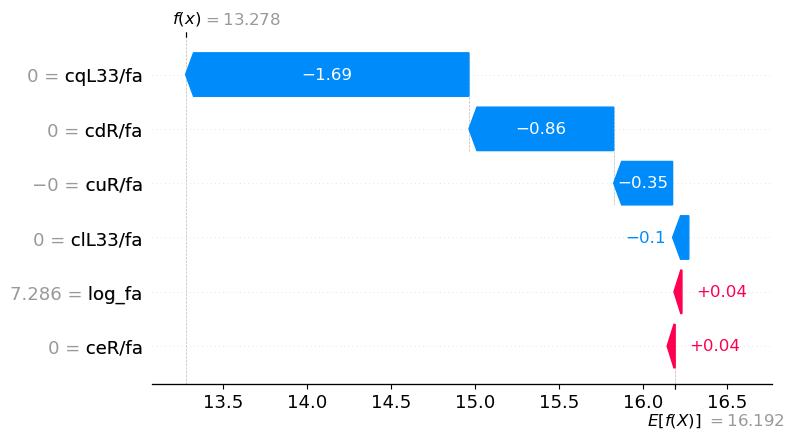

In [9]:
shap.waterfall_plot(explainer(x0)[0])

## Global explanations

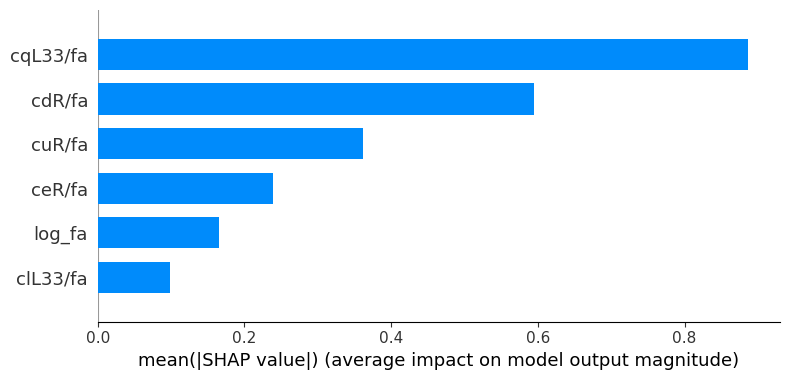

In [10]:
shap_values = explainer.shap_values(shap_sample)
shap.summary_plot(shap_values, shap_sample, plot_type='bar')

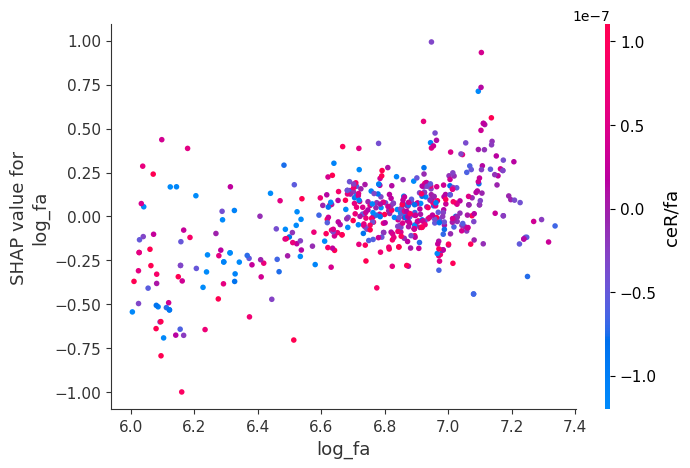

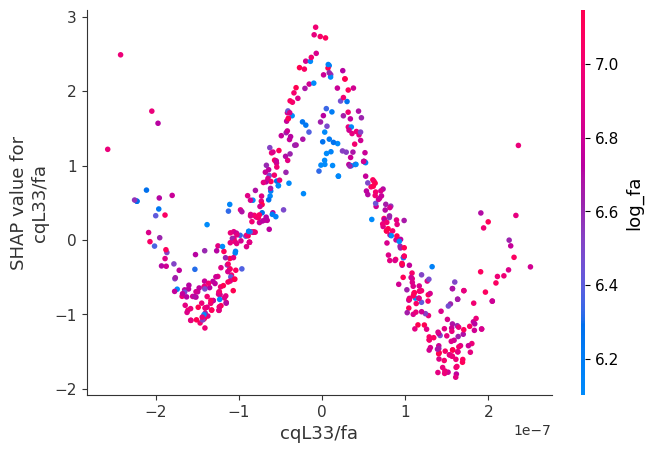

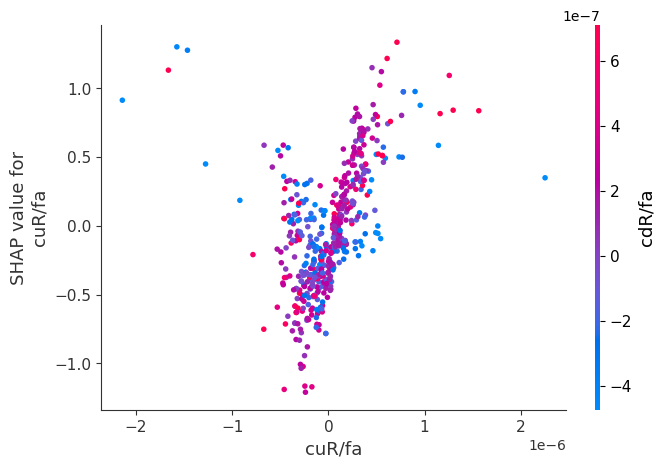

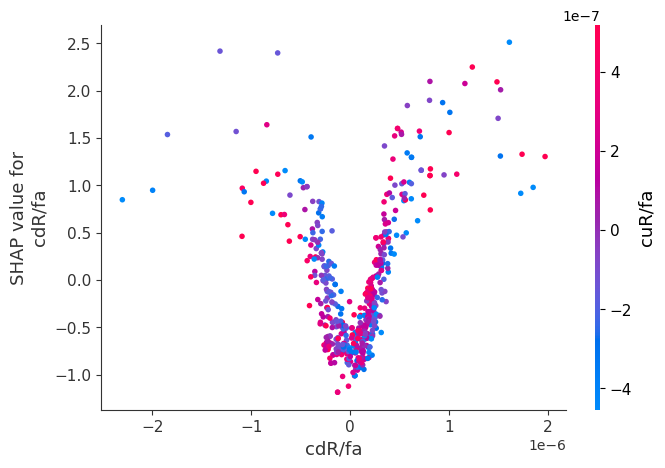

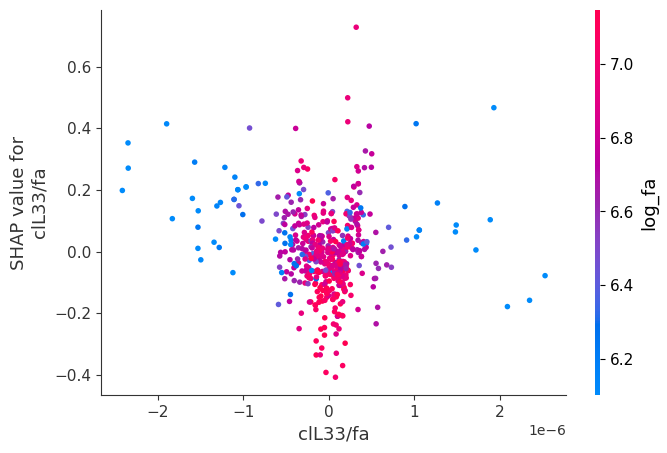

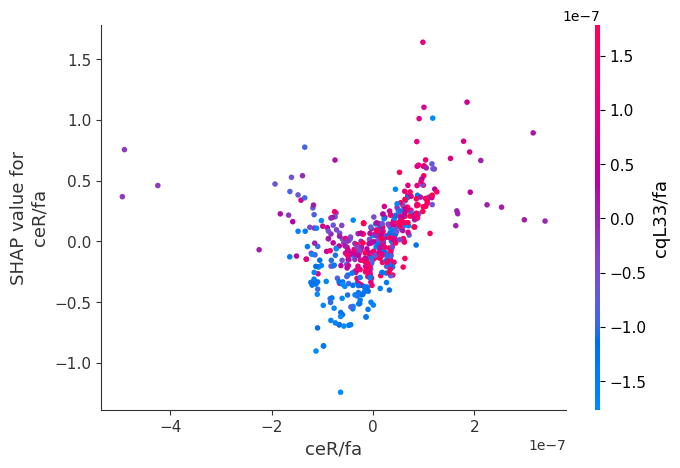

In [11]:
for name in X.columns:
    shap.dependence_plot(name, shap_values, shap_sample)

## Interactions between features

In [12]:
explainer_int = shapiq.TreeExplainer(model, max_order=2)

In [13]:
interaction_values = explainer_int.explain(x0.values[0])
print(interaction_values)

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=None,
    n_players=6, baseline_value=16.188547589506925,
    Top 10 interactions:
        (): 16.188547589506925
        (np.int64(5),): 0.3668893701730711
        (np.int64(2),): -0.14407167110284563
        (np.int64(0), np.int64(1)): -0.20578076720648603
        (np.int64(1), np.int64(5)): -0.2666053920538768
        (np.int64(3), np.int64(5)): -0.2672364671343189
        (np.int64(1), np.int64(3)): -0.2705186528860214
        (np.int64(0),): -0.3228808996985115
        (np.int64(3),): -0.5105026262011313
        (np.int64(1),): -1.1994701980555633
)


(<Figure size 700x700 with 1 Axes>, <Axes: >)

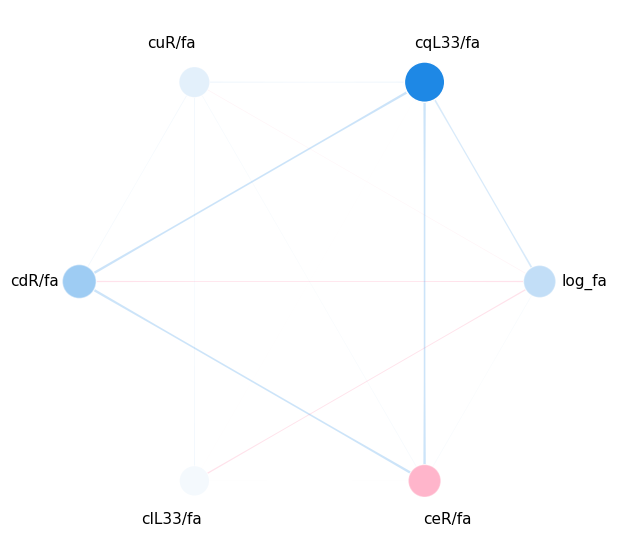

In [14]:
shapiq.network_plot(interaction_values, feature_names=['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa'])

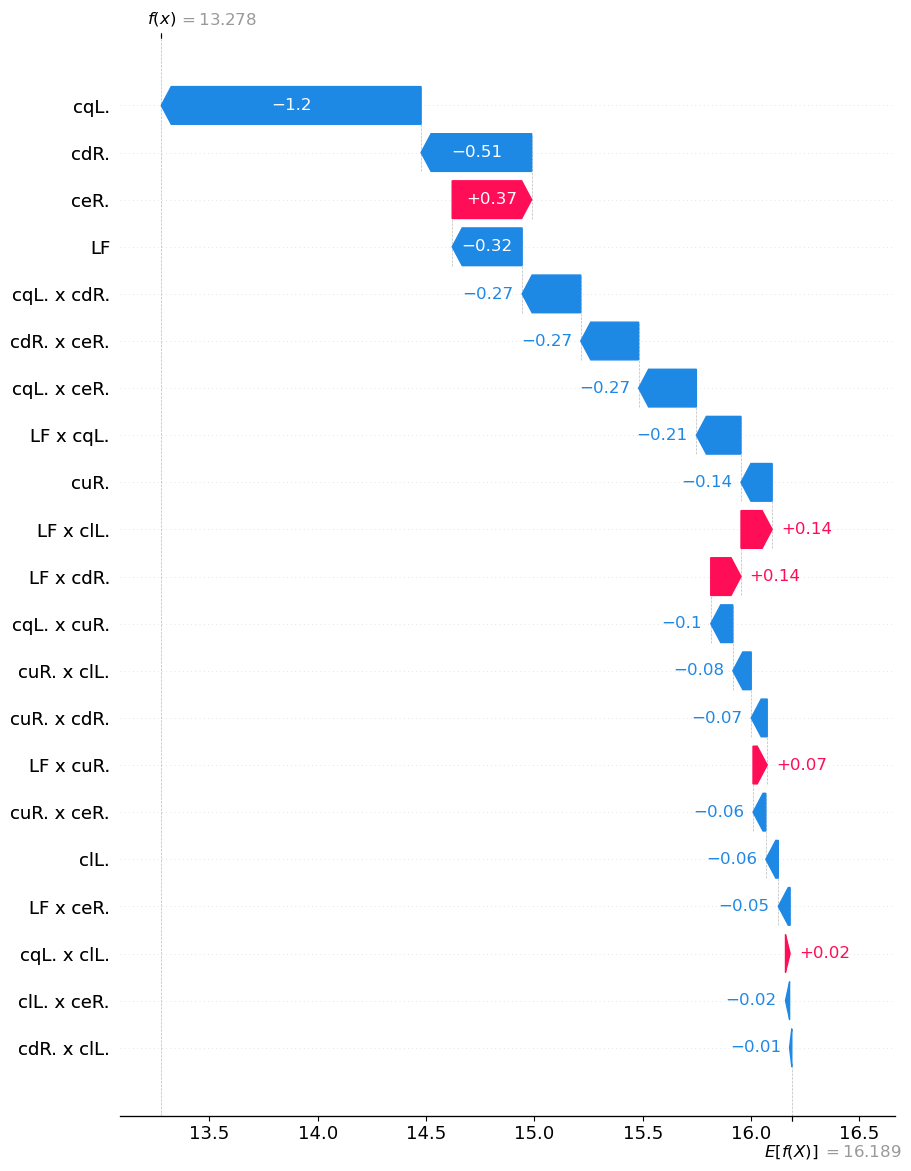

In [15]:
shapiq.waterfall_plot(interaction_values, feature_names=['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa'], show=True, max_display=21)

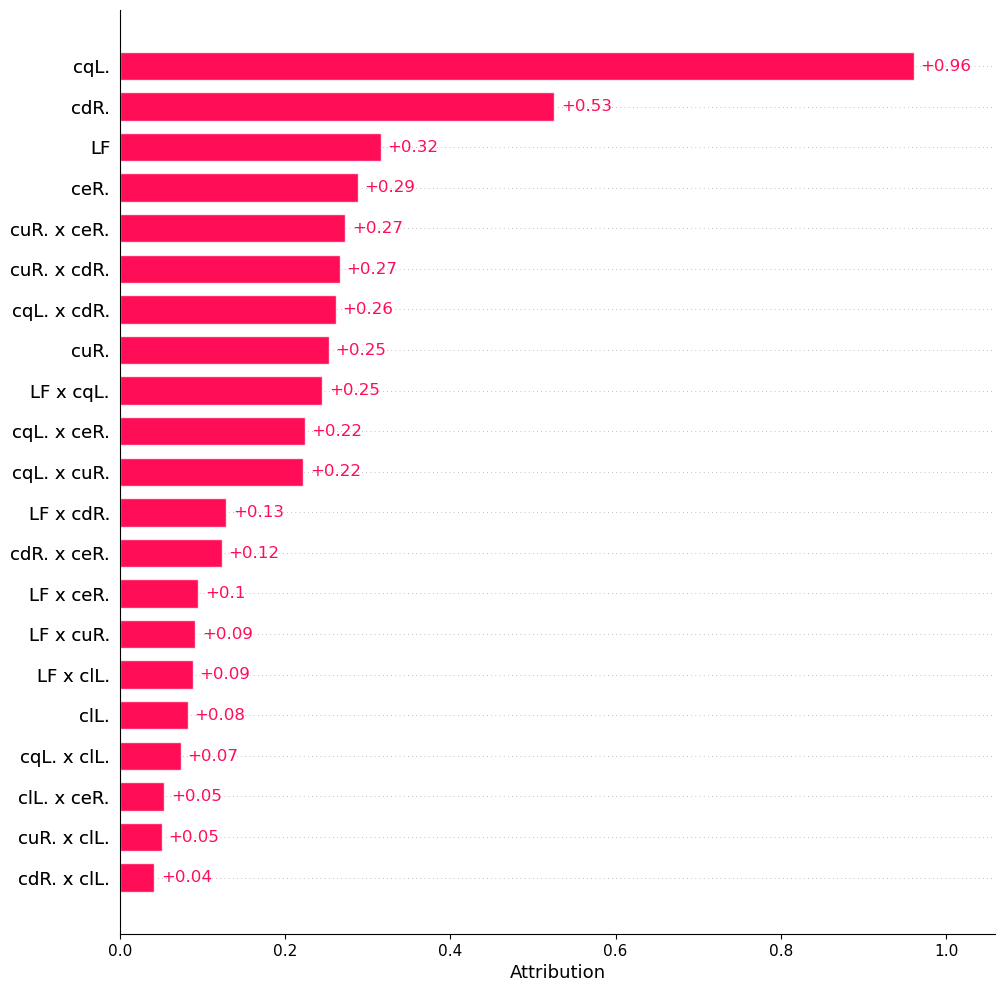

In [17]:
if False: #Long calculation
    shapiq_values = explainer_int.explain_X(shap_sample.values[:,:20])
    shapiq.plot.bar_plot(shapiq_values, feature_names=['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa'], max_display=21, show=True)